## Obtain the Antenna S11 for B+18 pipeline

In [1]:
import hickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un

from edges.cal import CalibratedS11, S11ModelParams
from edges import modeling as mdl
from edges.frequencies import get_mask, edges_raw_freqs

In [2]:
h2case_dir: str = "/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData"
legacy_data_dir: str = "/home/smurray/data7/edges/projects_with_nive/edges-bowman2018-pipeline/input-data"
outdir: str = "."

In [3]:
# Parameters
outdir = "."


In [4]:
outdir = Path(outdir)
if not outdir.exists():
    outdir.mkdir()
    
legacy_data_dir = Path(legacy_data_dir)

In [5]:
plt.style.use("dark_background")

In [6]:
s11freq, s11real, s11imag = np.genfromtxt(
   legacy_data_dir /"S11_blade_low_band_2015_342_03_14.txt.csv", skip_header=1, delimiter=","
).T

In [7]:
s11freq <<= un.Hz

mask = get_mask(s11freq, low=50 * un.MHz, high=100.0 * un.MHz)

s11freq = s11freq[mask]

In [8]:
spec_freqs = edges_raw_freqs(f_low=50*un.MHz, f_high=100*un.MHz)[2::8]

In [9]:
ants11 = CalibratedS11(
    s11=(s11real + s11imag * 1j)[mask],
    freqs=s11freq,
).smoothed(
    S11ModelParams(
        model=mdl.Polynomial(n_terms=10, transform=mdl.LogTransform(scale=1.0)),       
        complex_model_type=mdl.ComplexRealImagModel,
        set_transform_range=True,
        fit_method='lstsq',
        find_model_delay=True,
    ),
    freqs=spec_freqs
)

In [10]:
alan = np.genfromtxt(f"{h2case_dir}/627/modeled_antenna_s11.txt")

In [11]:
mymod = ants11.s11

In [12]:
alans11 = alan[:, 1] + 1j*alan[:, 2]

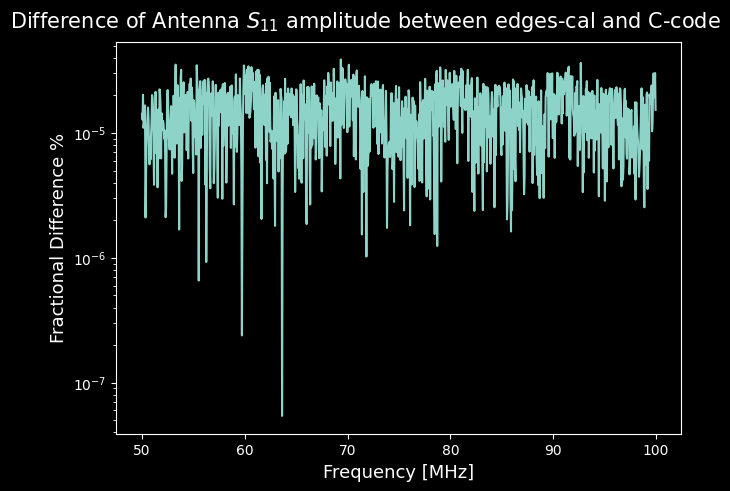

In [13]:
fig, ax = plt.subplots(1, 1, sharex=True, constrained_layout=True, gridspec_kw={'hspace': 0})

ax.plot(alan[:, 0], 100*np.abs(alans11 - mymod)/np.abs(mymod))
ax.set_yscale('log')

# ax[1].plot(alan[:, 0], np.unwrap(np.angle(alans11-mymod)))
# ax[1].set_ylabel("Phase Difference [rad]")
#plt.plot(alan[:, 0], alan[:, 2] - mymod.imag)
ax.set_xlabel("Frequency [MHz]", fontsize=13)
ax.set_ylabel("Fractional Difference %", fontsize=13)
fig.suptitle("Difference of Antenna $S_{11}$ amplitude between edges-cal and C-code", fontsize=15);

In [14]:
ants11.write(f"{outdir}/2015_ants11_modelled.h5")